# Application Scoring and Data Cleaning

## 1. Loading the Applications Dataset

In this step, the `applications.csv` file is loaded into a Pandas DataFrame for further analysis and data cleaning.

In [62]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from datetime import datetime

In [60]:
applications = pd.read_csv("applications(2.0).csv")
applications.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


In [19]:
industries = pd.read_csv("industries(2.0).csv")
industries.head()

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15


## 2. Cleaning the Applications Dataset

In this step, duplicate rows are removed based on the `applicant_id` column. Missing values in `External Rating` are filled with 0, and missing values in `Education level` are filled with "MiddleSchool".

In [29]:
applications1 = applications.drop_duplicates(subset="applicant_id")
applications1.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


In [35]:
applications1["External Rating"].value_counts(dropna=False)

External Rating
3.0     2185
1.0     1964
4.0     1438
2.0     1416
5.0     1337
6.0      976
7.0      783
10.0     593
15.0     581
8.0      524
0.0      524
9.0      331
11.0     231
12.0     204
13.0      96
14.0      95
Name: count, dtype: int64

In [52]:
applications1["External Rating"] = applications1["External Rating"].fillna(0)
applications1.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3


In [34]:
applications1["External Rating"].value_counts(dropna=False)

External Rating
3.0     2185
1.0     1964
4.0     1438
2.0     1416
5.0     1337
6.0      976
7.0      783
10.0     593
15.0     581
8.0      524
0.0      524
9.0      331
11.0     231
12.0     204
13.0      96
14.0      95
Name: count, dtype: int64

In [42]:
applications1["Education level"].value_counts(dropna=False)

Education level
Вища (бакалавр, спеціаліст, магістр)    10594
Дві вищі                                  994
Ще студент вишу                           806
Середня                                   444
Середня спеціальна                        407
0                                          33
Name: count, dtype: int64

### NOTE
For the fact that there is not any NaN value, I had to replace 0 values with NaN so that the code would make any difference at all.

In [50]:
applications1["Education level"] = applications1["Education level"].replace([0, "0"], np.nan)
applications1["Education level"] = applications1["Education level"].fillna("MiddleSchool")

In [51]:
applications1["Education level"].value_counts(dropna=False)

Education level
Вища (бакалавр, спеціаліст, магістр)    10594
Дві вищі                                  994
Ще студент вишу                           806
Середня                                   444
Середня спеціальна                        407
MiddleSchool                               33
Name: count, dtype: int64

## 3. Adding Industry Scores

In this step, the `industries.csv` file is loaded into a separate DataFrame. Then, the industry score data is merged with the applications DataFrame using the `Industry` column.

In [55]:
merged_file = pd.merge(applications1, industries, left_on="Industry", right_on="Industry", how="left")
merged_file.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Score
0,11.30.2022 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,0
1,11.30.2022 10:26:39,NaN,36,Чоловік,Public services / Government,Single,3.0,"Вища (бакалавр, спеціаліст, магістр)",NaN,63dfcf8e6904186650d6814279fbe42f,20
2,11.30.2022 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,10
3,11.30.2022 10:27:31,1500.0,23,Жінка,Telecom,Single,0.0,"Вища (бакалавр, спеціаліст, магістр)",Львів чи область,5847ac62cc9eac5e323c2517dcc91ad1,15
4,11.30.2022 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,15


In [57]:
merged_file[["Industry", "Score"]].head()

,Industry,Score
0,Blockchain,0
1,Public services / Government,20
2,Adtech / Advertising,10
3,Telecom,15
4,Automotive,15


## 4. Calculating Application Scores

In this step, an application score is calculated based on six conditions: age, application date, marital status, location, industry score, and external rating. If `Amount` is missing or `External Rating` is 0, the final score is set to 0.

In [78]:
merged_file["Applied at"] = pd.to_datetime(merged_file["Applied at"], format="mixed")

merged_file["Industry Score"] = merged_file["Score"].fillna(0)

merged_file["Application Score"] = (
    ((merged_file["Age"] >= 35) & (merged_file["Age"] <= 55)) * 20
    + (merged_file["Applied at"].dt.weekday < 5) * 20
    + (merged_file["Marital status"] == "Married") * 20
    + (merged_file["Location"].str.contains("Київ|Kyiv|Kiev", case=False, na=False)) * 10
    + merged_file["Industry Score"]
    + (merged_file["External Rating"] >= 7) * 20
    - (merged_file["External Rating"] <= 2) * 20
)

merged_file.loc[
    merged_file["Amount"].isna() | (merged_file["External Rating"] == 0),
    "Application Score"
] = 0

merged_file["Application Score"] = merged_file["Application Score"].clip(0, 100)

merged_file[[
    "Age",
    "Applied at",
    "Marital status",
    "Location",
    "Industry",
    "Industry Score",
    "External Rating",
    "Amount",
    "Application Score"
]].head()

,Age,Applied at,Marital status,Location,Industry,Industry Score,External Rating,Amount,Application Score
0,29,2022-11-30 10:26:37,Other,Івано-Франківськ чи область,Blockchain,0,8.0,12000.0,40
1,36,2022-11-30 10:26:39,Single,NaN,Public services / Government,20,3.0,NaN,0
2,34,2022-11-30 10:26:58,Single,Київ чи область,Adtech / Advertising,10,4.0,7500.0,40
3,23,2022-11-30 10:27:31,Single,Львів чи область,Telecom,15,0.0,1500.0,0
4,33,2022-11-30 10:27:34,Single,Житомир чи область,Automotive,15,6.0,8400.0,35


## 5. Filtering Accepted Applications

In this step, only applications with an `Application Score` greater than 0 are kept. These applications are considered accepted.

In [116]:
accepted_applications = merged_file[merged_file["Application Score"] > 0].copy()

accepted_applications.head()

,Applied at,Amount,Age,Gender,Industry,Marital status,External Rating,Education level,Location,applicant_id,Score,Industry Score,Application Score,Days,Weeks,Years
0,2022-11-30 10:26:37,12000.0,29,Чоловік,Blockchain,Other,8.0,"Вища (бакалавр, спеціаліст, магістр)",Івано-Франківськ чи область,99e7b0dc6cc05dd334d8f38dc26ce9b3,0,0,40,Wednesday,48,2022
2,2022-11-30 10:26:58,7500.0,34,Чоловік,Adtech / Advertising,Single,4.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,10dbafaeb46c09e96b6987c03bbb3498,10,10,40,Wednesday,48,2022
4,2022-11-30 10:27:34,8400.0,33,Жінка,Automotive,Single,6.0,"Вища (бакалавр, спеціаліст, магістр)",Житомир чи область,5d21f3795b50de8e8f8f8d5f48b754f3,15,15,35,Wednesday,48,2022
5,2022-11-30 10:27:38,16500.0,31,Чоловік,E-commerce,Single,8.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,f720bf9c5c4c3e10a8568c1699847696,15,15,65,Wednesday,48,2022
6,2022-11-30 10:27:42,4200.0,30,Чоловік,Media,Married,1.0,"Вища (бакалавр, спеціаліст, магістр)",Київ чи область,0aaf59fb3ef90f50ccd4800312e5c271,5,5,35,Wednesday,48,2022


## 6. Weekly Average Score of Accepted Applications

In this step, accepted applications are grouped by application week. Then, the average application score for each week is visualized using a line chart.

In [117]:
accepted_applications["Days"] = merged_file["Applied at"].dt.day_name()

In [118]:
accepted_applications["Days"].value_counts(dropna=False)

Days
Wednesday    4189
Monday       2434
Thursday     2010
Tuesday      1278
Friday       1136
Saturday      981
Sunday        530
Name: count, dtype: int64

In [119]:
accepted_applications["Weeks"] = accepted_applications["Applied at"].dt.isocalendar().week

In [120]:
accepted_applications["Weeks"].value_counts(dropna=False)

Weeks
48    3955
49    3293
50    2163
52    1412
51    1077
1      650
2        8
Name: count, dtype: Int64

In [121]:
accepted_applications["Years"] = accepted_applications["Applied at"].dt.year

In [122]:
accepted_applications["Years"].value_counts(dropna=False)

Years
2022    11887
2023      671
Name: count, dtype: int64

In [123]:
accepted_applications[["Years", "Weeks", "Application Score"]]

,Years,Weeks,Application Score
0,2022,48,40
2,2022,48,40
4,2022,48,35
5,2022,48,65
6,2022,48,35
...,...,...,...
13273,2023,2,35
13274,2023,2,40
13275,2023,2,40
13276,2023,2,55


In [124]:
accepted_applications.groupby(["Years", "Weeks"])["Application Score"].mean()

Years  Weeks
2022   48       50.644753
       49       49.448831
       50       49.773463
       51       46.959146
       52       51.043603
2023   1        51.484615
       2        51.875000
       52       40.384615
Name: Application Score, dtype: float64

In [125]:
final_look = accepted_applications.groupby(["Years", "Weeks"])["Application Score"].mean().reset_index()

In [92]:
final_look

,Years,Weeks,Application Score
0,2022,48,47.251710
1,2022,49,47.515320
2,2022,50,47.532009
3,2022,51,43.863833
4,2022,52,48.348003
5,2023,1,48.151079
6,2023,2,51.875000
7,2023,52,37.500000


Text(0.5, 1.0, 'Weekly Average Score by Year')

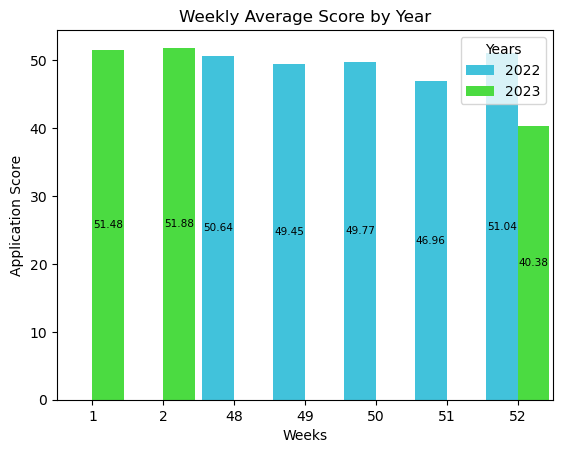

In [140]:
ax = sns.barplot(
    x="Weeks",
    y="Application Score",
    hue="Years",
    data=final_look,
    palette=["#27D3F5", "#35F527"],
    width=0.9
)
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[round(x, 2) for x in container.datavalues],
        rotation=0,
        label_type="center",
        fontsize=7.5
)
ax.set_title("Weekly Average Score by Year")